# Automated crystal orientation mapping (ACOM) of AuAgPd nanowires

This notebook maps the **crystal orientation** at every probe position of a 4D-STEM scan of AuAgPd nanowires, using **automated crystal orientation mapping (ACOM)** — the electron-diffraction analogue of EBSD, but with nanometer resolution and working in transmission.

**The idea.** A crystal's diffraction pattern depends on how the lattice is oriented relative to the beam. If we *simulate* the expected pattern for many candidate orientations of a known crystal structure, we can compare each *measured* pattern against that dictionary and keep the best match. py4DSTEM implements this efficiently with a spherical-harmonic correlation ("orientation plan"), as described in [Ophus et al., Microsc. Microanal. 28 (2022)](https://doi.org/10.1017/S1431927622000101).

**The workflow:**
1. detect the Bragg disks (as always!),
2. clean up artifacts — this experiment used a **beamstop**, which creates false detections we must mask away,
3. calibrate: center, elliptical distortion, rotation, and the **pixel size** — calibrated here against the known gold lattice parameter,
4. build an orientation plan from the crystal structure and match every pattern.

This dataset also introduces a **bullseye probe**: the probe-forming aperture has patterned rings, which makes disk *positions* easier to measure precisely on a noisy background (at some cost in intensity).

*Prerequisite: the basics notebook.*

---

## Tutorial data

The notebook downloads its data automatically. Direct links:

* [AuAgPd wire 4D-STEM dataset](https://drive.google.com/file/d/1OQYW0H6VELsmnLTcwicP88vo2V5E3Oyt/view?usp=sharing) (2.0 GB)
* [AuAgPd vacuum probe dataset](https://drive.google.com/file/d/17OduUKpxVBDumSK_VHtnc2XKkaFVN8kq/view?usp=sharing)

### Acknowledgements

This tutorial was created by the py4DSTEM instructor team:
Ben Savitzky, Steve Zeltmann, Stephanie Ribet (sribet@lbl.gov), Alex Rakowski, and Colin Ophus (cophus@stanford.edu).

### Running this notebook

This notebook is designed for **Google Colab** — every cell also runs in a local Jupyter session with py4DSTEM installed. Run the cells top to bottom; each section explains what it does and why before the code.

# Set up the environment

In [1]:
# Install py4DSTEM and pymatgen (crystal structures). On Google Colab this
# takes a few minutes -- start it now and read ahead while you wait!
# %pip install -q git+https://github.com/cophus/py4DSTEM.git@dev pymatgen anywidget
# (once the numpy-2 fix is merged upstream, this becomes:
%pip install -q git+https://github.com/py4dstem/py4DSTEM.git@dev pymatgen

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 272.8/272.8 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.9/302.9 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 369.9/369.9 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62

If Colab shows a message asking you to **restart the session** after the installation finishes, do so (*Runtime → Restart session*) and then continue from the imports cell below — the installed packages are kept.

In [2]:
import py4DSTEM
import numpy as np
import matplotlib.pyplot as plt

print('py4DSTEM version:', py4DSTEM.__version__)

py4DSTEM version: 0.14.19


# Download and load the data

Two files this time: the 4D-STEM scan of the wires (2 GB — this download is the slowest step of the notebook), and a separately recorded **vacuum probe** dataset. Recording the probe over vacuum during your session is best practice: it gives a clean template for disk detection, with no guesswork.

In [3]:
import os

dirpath = '/content/'
filepath_data = dirpath + 'small_AuAgPd_wire_dataset_04.h5'
filepath_probe = dirpath + 'downsampled_AuAgPd_wire_probe.h5'
filepath_analysis = dirpath + 'AuAgPd_analysis_'

if not os.path.exists(filepath_data):
    py4DSTEM.io.gdrive_download(
        id_ = 'https://drive.google.com/uc?id=1OQYW0H6VELsmnLTcwicP88vo2V5E3Oyt',
        destination = dirpath,
        filename = 'small_AuAgPd_wire_dataset_04.h5',
        overwrite = True,
    )
if not os.path.exists(filepath_probe):
    py4DSTEM.io.gdrive_download(
        id_ = 'https://drive.google.com/uc?id=17OduUKpxVBDumSK_VHtnc2XKkaFVN8kq',
        destination = dirpath,
        filename = 'downsampled_AuAgPd_wire_probe.h5',
        overwrite = True,
    )

Downloading...
From (original): https://drive.google.com/uc?id=1OQYW0H6VELsmnLTcwicP88vo2V5E3Oyt
From (redirected): https://drive.google.com/uc?id=1OQYW0H6VELsmnLTcwicP88vo2V5E3Oyt&confirm=t&uuid=849c98d8-7fcc-4bac-b45e-be835c1f44da
To: /content/small_AuAgPd_wire_dataset_04.h5
100%|██████████| 2.10G/2.10G [00:19<00:00, 106MB/s]
Downloading...
From: https://drive.google.com/uc?id=17OduUKpxVBDumSK_VHtnc2XKkaFVN8kq
To: /content/downsampled_AuAgPd_wire_probe.h5
100%|██████████| 19.0M/19.0M [00:00<00:00, 96.9MB/s]


In [4]:
dataset = py4DSTEM.read(filepath_data, data_id='datacube_0')
dataset_probe = py4DSTEM.read(filepath_probe, data_id='datacube_0')

dataset, dataset_probe

(DataCube( A 4-dimensional array of shape (62, 143, 172, 172) called 'datacube_0',
           with dimensions:
 
               Rx = [0,1,2,...] pixels
               Ry = [0,1,2,...] pixels
               Qx = [0,1,2,...] pixels
               Qy = [0,1,2,...] pixels
 ),
 DataCube( A 4-dimensional array of shape (5, 16, 172, 172) called 'datacube_0',
           with dimensions:
 
               Rx = [0,1,2,...] pixels
               Ry = [0,1,2,...] pixels
               Qx = [0,1,2,...] pixels
               Qy = [0,1,2,...] pixels
 ))

This file predates automatic calibration transfer, so we enter the pixel sizes from the microscope metadata by hand. Real-space pixels are the probe *step size* (5 Å here); diffraction-space pixels are in inverse Ångströms:

In [5]:
pixel_size_inv_Ang = 0.021
probe_step_size_Ang = 5.0

# diffraction space
dataset.calibration.set_Q_pixel_size(pixel_size_inv_Ang)
dataset.calibration.set_Q_pixel_units('A^-1')
dataset_probe.calibration.set_Q_pixel_size(pixel_size_inv_Ang)
dataset_probe.calibration.set_Q_pixel_units('A^-1')

# real space
dataset.calibration.set_R_pixel_size(probe_step_size_Ang)
dataset.calibration.set_R_pixel_units('A')

# Examine the data

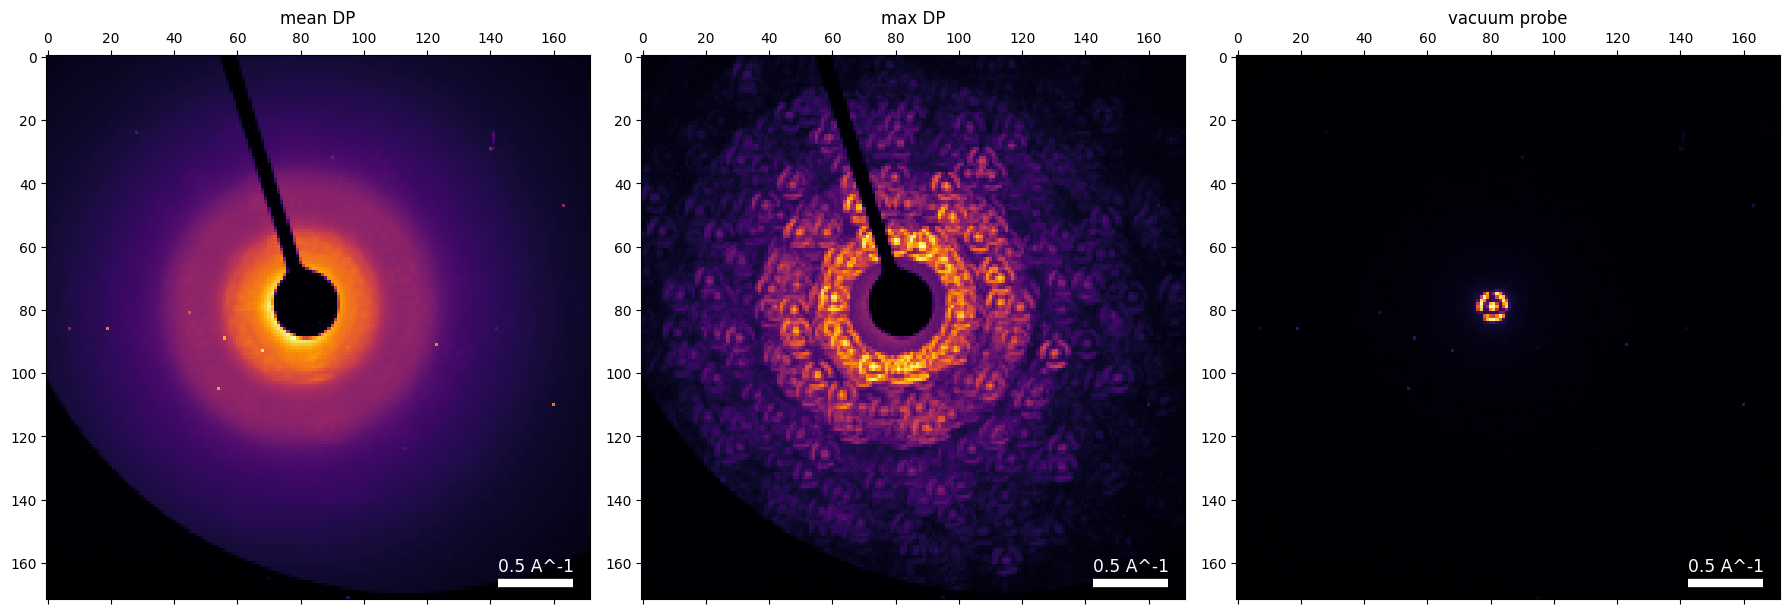

In [6]:
dataset.get_dp_max();
dataset.get_dp_mean();
dataset_probe.get_dp_mean();

py4DSTEM.show(
    [
        dataset.tree('dp_mean'),
        dataset.tree('dp_max'),
        dataset_probe.tree('dp_mean'),
    ],
    vmax = 1,
    power = 0.5,
    cmap = 'inferno',
    title = ['mean DP', 'max DP', 'vacuum probe'],
)

Three things to notice:

- The **bullseye rings** in the probe (right panel) — every Bragg disk in this dataset will have this ring structure.
- The dark wedge and central shadow in the mean/max patterns: that is the **beamstop**, a physical arm blocking the intense direct beam to protect the detector. It will produce false disk detections that we must remove.
- Rings of many Bragg disks in the max pattern — the wires are polycrystalline.

# Virtual imaging

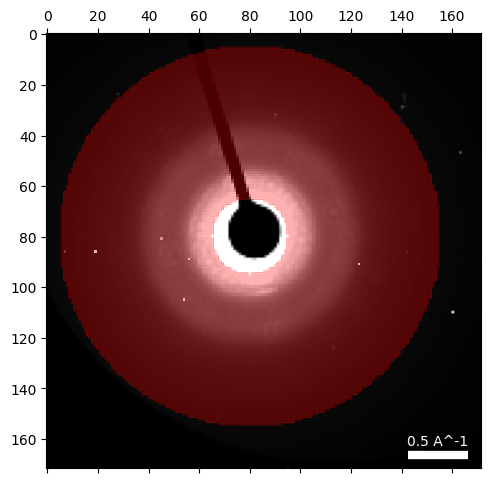

100%|██████████| 8866/8866 [00:00<00:00, 12962.68it/s]


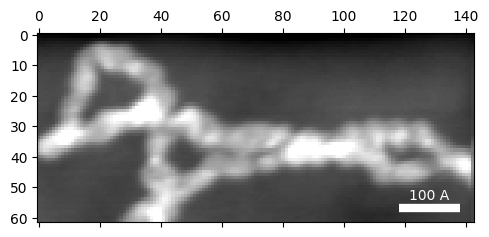

In [7]:
center = (80, 80)
radii = (15, 75)

dataset.position_detector(
    mode = 'annular',
    geometry = (center, radii),
)

dataset.get_virtual_image(
    mode = 'annulus',
    geometry = (center, radii),
    name = 'dark_field',
)

py4DSTEM.show(dataset.tree('dark_field'))

## Browse the data interactively

Before running any analysis, it is *always* worth exploring a 4D-STEM dataset by hand. The cell below downloads a small interactive browser widget: **click or drag on the left (real-space) panel to move the electron probe**, and the right panel shows the diffraction pattern recorded at that position.

Each panel has its own contrast controls: the small histogram below the image shows the distribution of displayed intensities — **drag the two blue markers** to set the display window (it defaults to the 2%–98% intensity quantiles) — and the **power slider** compresses the dynamic range (diffraction spans many orders of magnitude, so powers well below 1 are usually best on the right panel).

Browsing builds intuition fast: where the sample is, how strongly it diffracts, whether the patterns shift on the detector, and what artifacts to look out for.

In [8]:
# Download the interactive 4D-STEM data browser widget.
import os, sys

if not os.path.exists('/content/browse_4dstem.py'):
    py4DSTEM.io.gdrive_download(
        id_ = 'https://drive.google.com/uc?id=1dFK5GZ8Eq9TX_ENjLp5P_K2pbsfbs00c',
        destination = '/content/',
        filename = 'browse_4dstem.py',
    )
sys.path.append('/content')

# on Colab, third-party widgets need the custom widget manager enabled
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass   # not on Colab

from browse_4dstem import browse_4dstem

Downloading...
From (original): https://drive.google.com/uc?id=1dFK5GZ8Eq9TX_ENjLp5P_K2pbsfbs00c
From (redirected): https://drive.google.com/uc?id=1dFK5GZ8Eq9TX_ENjLp5P_K2pbsfbs00c&confirm=t&uuid=3dbd13c6-8db0-4ef9-939f-a965d8fbc534
To: /content/browse_4dstem.py
100%|██████████| 17.1k/17.1k [00:00<00:00, 18.9MB/s]


In [9]:
browse_4dstem(
    dataset.data,
    nav_image = dataset.tree('dark_field').data,
)

As you move along a wire, watch the whole diffraction pattern change from one single-crystal pattern to another — each wire segment is a grain with its own orientation. That per-position pattern is exactly what ACOM will decode.

Choose a few positions for parameter testing:

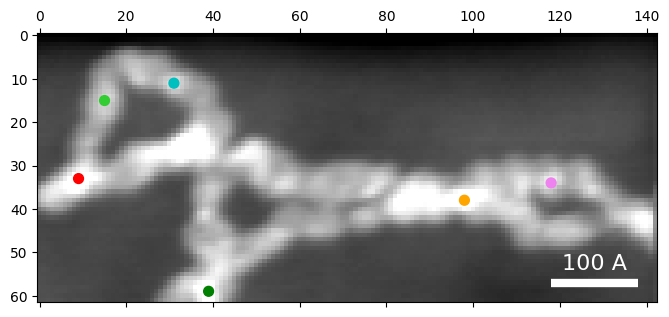

In [10]:
rxs = 33, 15, 11, 59, 38, 34
rys = 9, 15, 31, 39, 98, 118
colors = ['r', 'limegreen', 'c', 'g', 'orange', 'violet']

py4DSTEM.visualize.show_points(
    dataset.tree('dark_field'),
    x = rxs, y = rys,
    pointcolor = colors,
    figsize = (8, 8),
)

# Construct the probe template

The vacuum probe was recorded while scanning, so the individual probe images are slightly shifted relative to each other — `get_vacuum_probe(align=True)` cross-correlates and aligns them before averaging. (The low `threshold` is needed because of the bullseye's ring structure.)

100%|██████████| 79/79 [00:00<00:00, 113.78it/s]


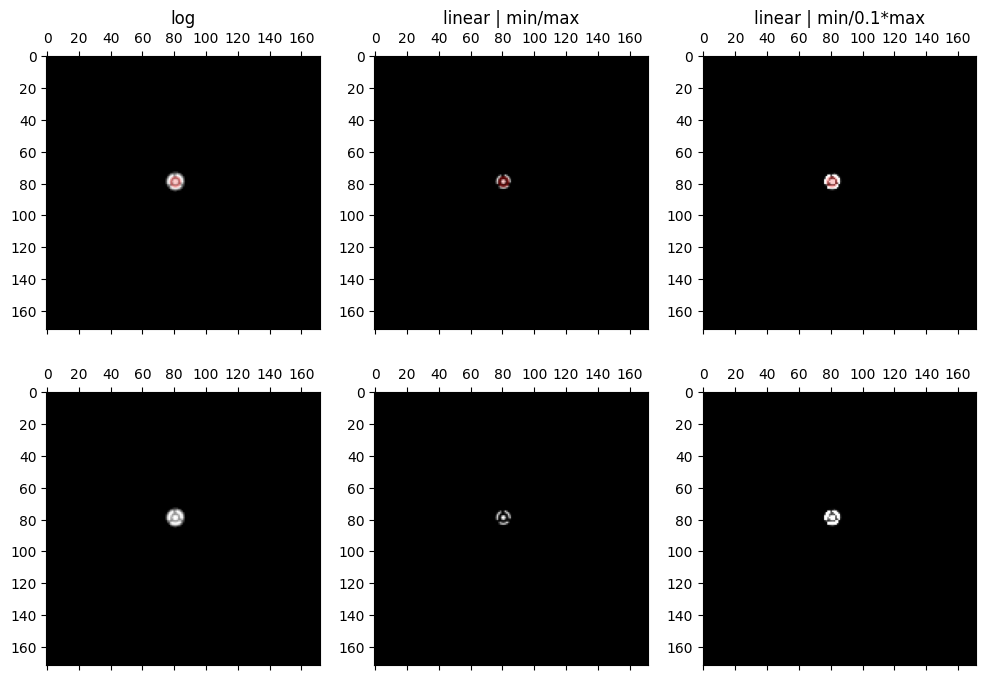

In [11]:
probe_align = dataset_probe.get_vacuum_probe(
    align = True,
)

In [12]:
probe_semiangle, probe_qx0, probe_qy0 = dataset_probe.get_probe_size(
    thresh_lower = 0.02,
    thresh_upper = 0.04,
    figsize = (4, 4),
)

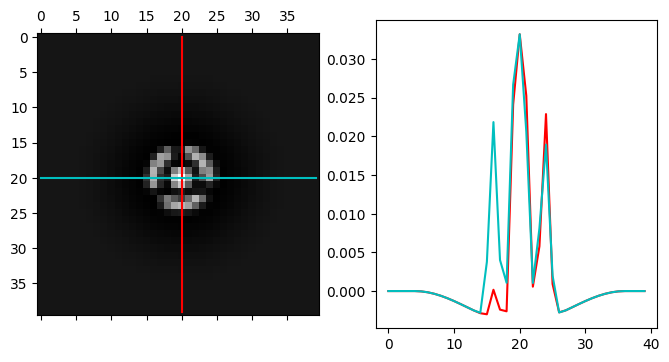

In [13]:
# build the correlation kernel from the aligned probe
probe_semiangle = 4
probe_kernel = probe_align.get_kernel(
    mode = 'sigmoid',
    radii = (probe_semiangle * 0.0, probe_semiangle * 4.0),
    bilinear = True,
)

py4DSTEM.visualize.show_kernel(
    probe_align.kernel,
    R = 20, L = 20, W = 1,
    figsize = (8, 4),
)

# Disk detection

Test the parameters on our six sample positions first. Note we use `subpixel='poly'` here: ACOM compares whole *patterns* of disks against simulations, so ~0.1 px precision is plenty — no need for the slower high-precision refinement that strain mapping demands.

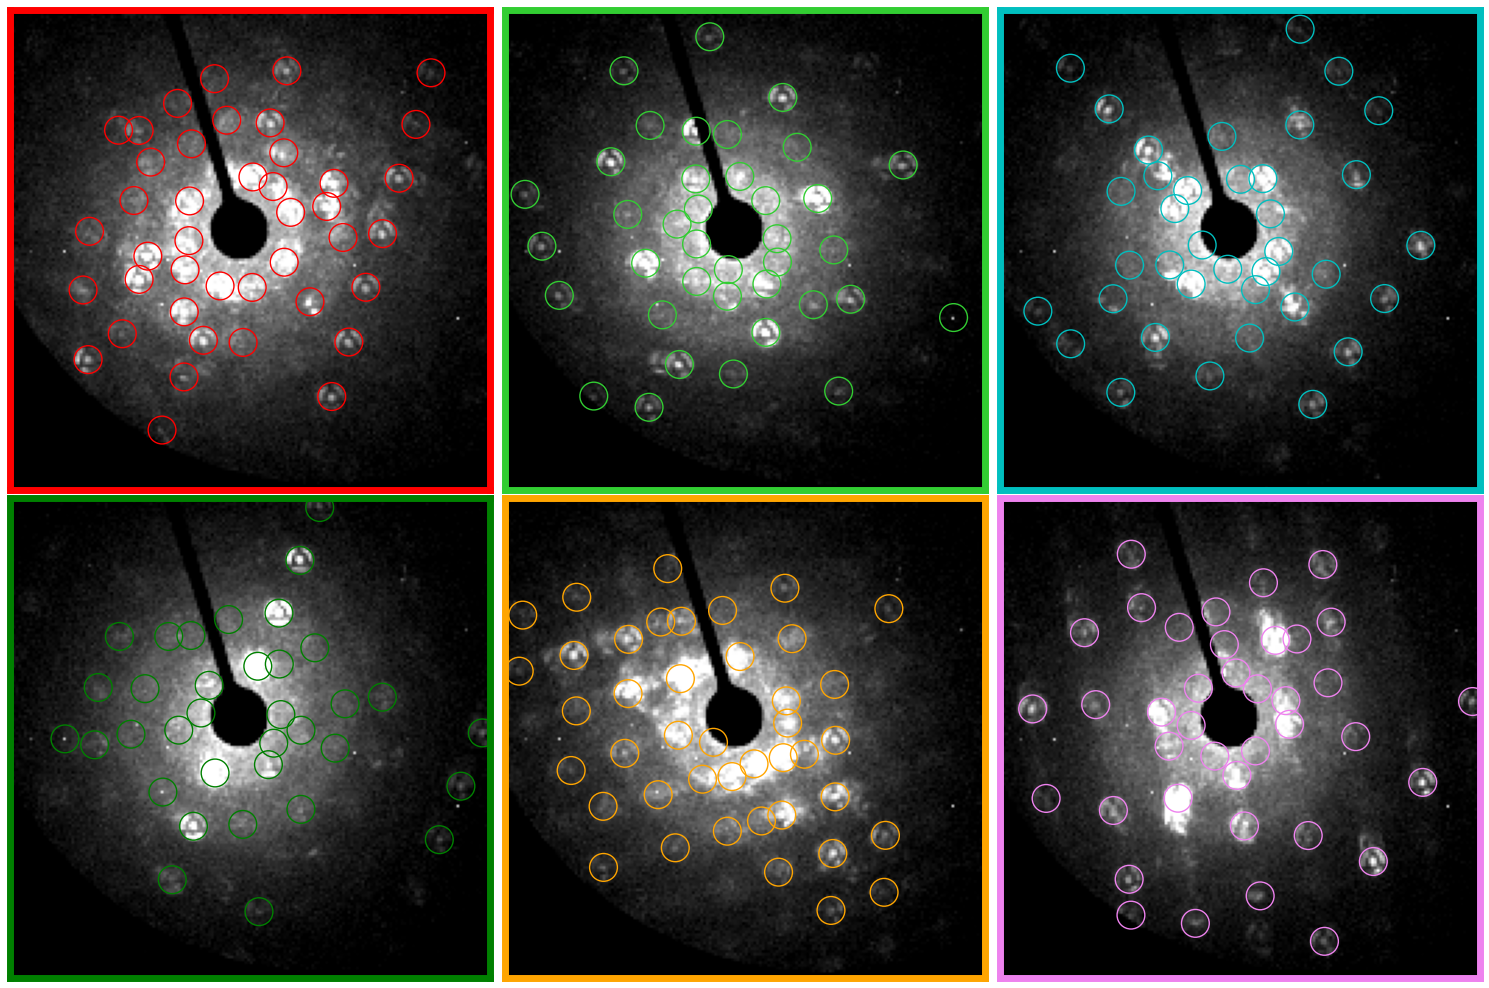

In [14]:
detect_params = {
    'corrPower': 1.0,
    'sigma': 0,
    'edgeBoundary': 2,
    'minRelativeIntensity': 0,
    'minAbsoluteIntensity': 10,
    'minPeakSpacing': 8,
    'subpixel': 'poly',
    'upsample_factor': 8,
    'maxNumPeaks': 1000,
}

disks_selected = dataset.find_Bragg_disks(
    data = (rxs, rys),
    template = probe_kernel,
    **detect_params,
)

py4DSTEM.visualize.show_image_grid(
    get_ar = lambda i: dataset.data[rxs[i], rys[i], :, :],
    H = 2, W = 3,
    axsize = (5, 5),
    intensity_range = 'absolute', vmin = 10, vmax = 500,
    scaling = 'power', power = 0.5,
    get_bordercolor = lambda i: colors[i],
    get_x = lambda i: disks_selected[i].data['qx'],
    get_y = lambda i: disks_selected[i].data['qy'],
    get_pointcolors = lambda i: colors[i],
    open_circles = True,
    scale = 400,
)

In [15]:
# find all the Bragg disks (a few minutes for this dataset)
bragg_peaks = dataset.find_Bragg_disks(
    template = probe_kernel,
    **detect_params,
)

Finding Bragg Disks: 100%|██████████| 8.87k/8.87k [00:57<00:00, 154DP/s]


In [16]:
# checkpoint: save the raw detection to disk
filepath_braggdisks_raw = filepath_analysis + 'braggdisks_raw.h5'
py4DSTEM.save(
    filepath_braggdisks_raw,
    bragg_peaks,
    mode = 'o',
)

100%|██████████| 8866/8866 [00:01<00:00, 4752.02it/s]


*(These checkpoint saves are a habit worth copying: disk detection on a big dataset takes minutes, and saving the result means you can restart analysis from here without redoing it.)*

# Remove beamstop false positives

The beamstop's sharp edges correlate with the probe template and generate false "disks" along the beamstop arm and around the blocked center. py4DSTEM can build a mask of the beamstop directly from the data — the beamstop region is the part of the detector that *never* records significant intensity at any probe position:

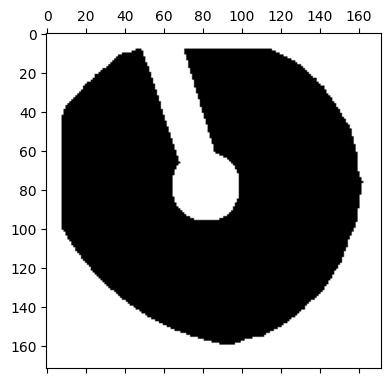

In [17]:
dataset.get_beamstop_mask(
    threshold = 0.25,
    distance_edge = 8,
);

py4DSTEM.show(
    dataset.tree('mask_beamstop'),
    intensity_range = 'absolute',
    vmin = 0, vmax = 1,
    figsize = (4, 4),
)

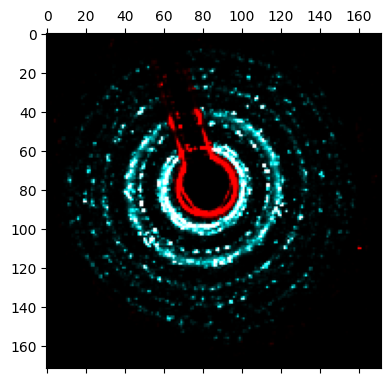

In [18]:
# drop every detected peak inside the masked region
bragg_peaks_masked = bragg_peaks.mask_in_Q(
    dataset.tree('mask_beamstop').data,
)

# compare Bragg vector maps before and after masking
bragg_vector_map = bragg_peaks.get_bvm(mode='raw')
bragg_vector_map_masked = bragg_peaks_masked.get_bvm(mode='raw')

py4DSTEM.show(
    [bragg_vector_map, bragg_vector_map_masked],
    combine_images = True,
    figsize = (4, 4),
)

# Calibration: center and elliptical distortion

With the direct beam behind a beamstop we cannot center on it. Instead we use the diffraction *rings*: since the wires are polycrystalline, the detected Bragg peaks fall on rings, and fitting an ellipse to a ring gives us the pattern center *and* the elliptical distortion in one step. First, pick a ring and a radial fitting range by eye:

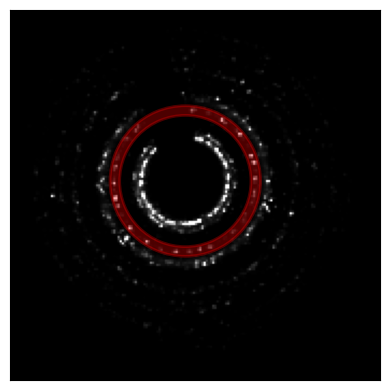

In [19]:
bragg_vector_map_masked = bragg_peaks_masked.get_bvm(mode='raw')

center_guess = (79, 81)
q_range = (30.5, 35.0)

py4DSTEM.show(
    bragg_vector_map_masked,
    intensity_range = 'absolute',
    vmin = 0, vmax = 1e4,
    annulus = {
        'center': center_guess,
        'radii': q_range,
        'fill': True, 'color': 'r', 'alpha': 0.3,
    },
    figsize = (4, 4),
    ticks = False,
)

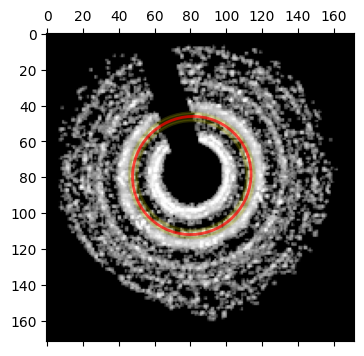

In [20]:
p_ellipse = bragg_peaks_masked.fit_p_ellipse(
    bragg_vector_map_masked,
    center = center_guess,
    fitradii = q_range,
    figsize = (4, 4),
    returncalc = True,
)

In [21]:
# store the fitted center
bragg_peaks_masked.calibration.set_origin(p_ellipse[:2])

# Calibration: rotation

The scan–detector rotation for this dataset was measured independently:

In [22]:
theta = -146.4067
flip = True

bragg_peaks_masked.calibration.set_QR_rotflip((theta, flip))

# Calibration: pixel size from a known lattice

Here is a trick you will use constantly: the most accurate diffraction pixel calibration comes from the *sample itself*, when it contains a phase with a known lattice parameter. Gold is face-centered cubic with $a = 4.08$ Å. We build the crystal, compute its **structure factors** (the set of allowed Bragg reflections and their intensities), and compare the predicted ring positions with our measured Bragg peaks:

In [23]:
a_lat = 4.08    # gold lattice parameter, Angstroms
atom_num = 79   # gold atomic number
k_max = 1.5     # compute structure factors out to this scattering vector (1/Angstroms)

# FCC basis: 4 atoms per cubic cell
pos = np.array([
    [0.0, 0.0, 0.0],
    [0.0, 0.5, 0.5],
    [0.5, 0.0, 0.5],
    [0.5, 0.5, 0.0],
])

crystal = py4DSTEM.process.diffraction.Crystal(pos, atom_num, a_lat)
crystal.calculate_structure_factors(k_max)

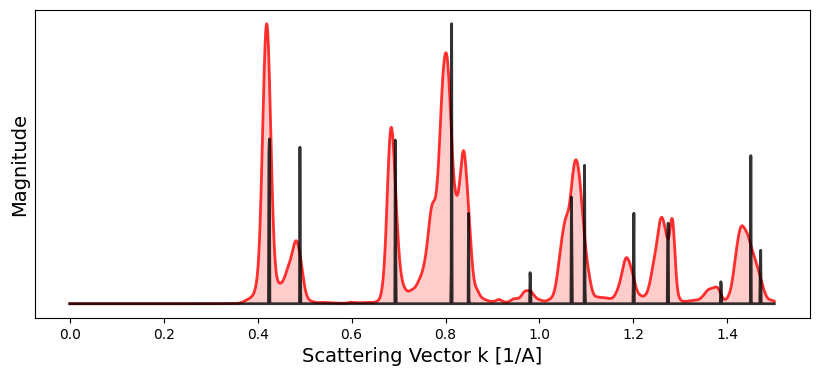

In [24]:
# compare measured peaks against the predicted gold rings
crystal.plot_scattering_intensity(
    bragg_peaks = bragg_peaks_masked,
    bragg_k_power = 2.0,
)

initial pixel size = 0.021 A^-1
Calibrated pixel size = 0.0212751 A^-1


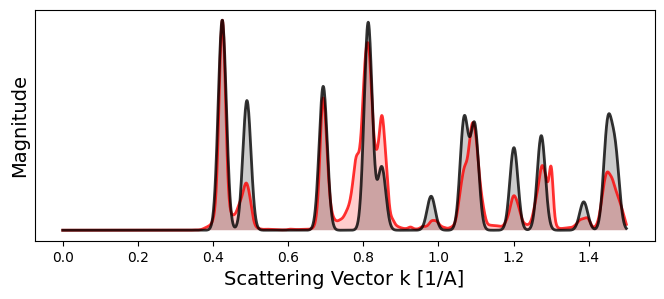

In [25]:
print('initial pixel size =',
      np.round(bragg_peaks_masked.calibration.get_Q_pixel_size(), 8),
      bragg_peaks_masked.calibration.get_Q_pixel_units())

# refine the pixel size so measured rings land on the predicted ones
bragg_peaks_cali = crystal.calibrate_pixel_size(
    bragg_peaks = bragg_peaks_masked,
    bragg_k_power = 2.0,
    plot_result = True,
    figsize = (8, 3),
)

In [26]:
# checkpoint: save the calibrated peaks
filepath_braggdisks_cali = filepath_analysis + 'braggdisks_cali.h5'
py4DSTEM.save(
    filepath_braggdisks_cali,
    bragg_peaks_cali,
    mode = 'o',
)

100%|██████████| 8866/8866 [00:01<00:00, 4492.89it/s]


# Automated crystal orientation mapping

## The orientation plan

The orientation plan is a precomputed dictionary: py4DSTEM simulates the diffraction pattern of our gold crystal over a grid of orientations covering the symmetry-reduced zone-axis space (for cubic crystals, the standard triangle between [001], [011], and [111]), each at a set of in-plane rotations. The `angle_step_*` parameters set the grid spacing — finer steps give more precise orientations but a bigger dictionary and slower matching.

In [27]:
crystal.orientation_plan(
    zone_axis_range = 'auto',
    angle_step_zone_axis = 2.0,
    angle_step_in_plane = 5.0,
    accel_voltage = 300e3,
)

Automatically detected point group m-3m,
 using arguments: zone_axis_range = 
[[0 1 1]
 [1 1 1]], 
 fiber_axis=None, fiber_angles=None.


Orientation plan: 100%|██████████| 406/406 [00:00<00:00, 8000.41 zone axes/s]


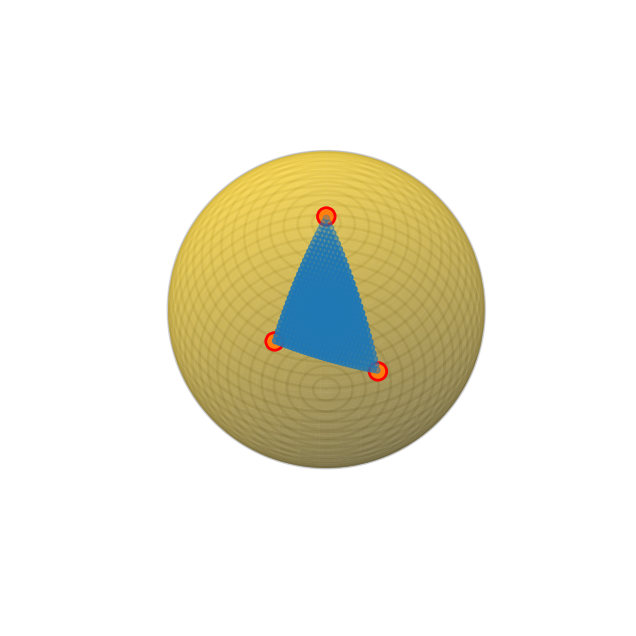

In [28]:
# visualize the orientation grid on the unit sphere
crystal.plot_orientation_zones(
    plot_zone_axis_labels = False,
)

## Test the matching on single patterns

Before matching all ~20,000 patterns, sanity-check a couple. The plots compare the measured peaks (open circles) with the simulated pattern of the best-fit orientation (dots) — a good match means nearly every measured peak has a simulated partner:

Best fit lattice directions: z axis = ([0.395 0.481 0.783]), x axis = ([0.118 0.562 0.819]), with corr value = 11.235
Best fit lattice directions: z axis = ([0.093 0.638 0.765]), x axis = ([0.112 0.644 0.756]), with corr value = 7.079
Best fit lattice directions: z axis = ([0.093 0.638 0.765]), x axis = ([0.112 0.644 0.756]), with corr value = 7.079


'parseAll' argument is deprecated, use 'parse_all'
'parseAll' argument is deprecated, use 'parse_all'
'parseAll' argument is deprecated, use 'parse_all'
'parseAll' argument is deprecated, use 'parse_all'
'parseAll' argument is deprecated, use 'parse_all'
'parseAll' argument is deprecated, use 'parse_all'
'parseAll' argument is deprecated, use 'parse_all'
'parseAll' argument is deprecated, use 'parse_all'
'parseAll' argument is deprecated, use 'parse_all'
'parseAll' argument is deprecated, use 'parse_all'
'parseAll' argument is deprecated, use 'parse_all'
'parseAll' argument is deprecated, use 'parse_all'
'parseAll' argument is deprecated, use 'parse_all'
'parseAll' argument is deprecated, use 'parse_all'
'parseAll' argument is deprecated, use 'parse_all'
'parseAll' argument is deprecated, use 'parse_all'
'parseAll' argument is deprecated, use 'parse_all'
'parseAll' argument is deprecated, use 'parse_all'
'parseAll' argument is deprecated, use 'parse_all'
'parseAll' argument is deprecat

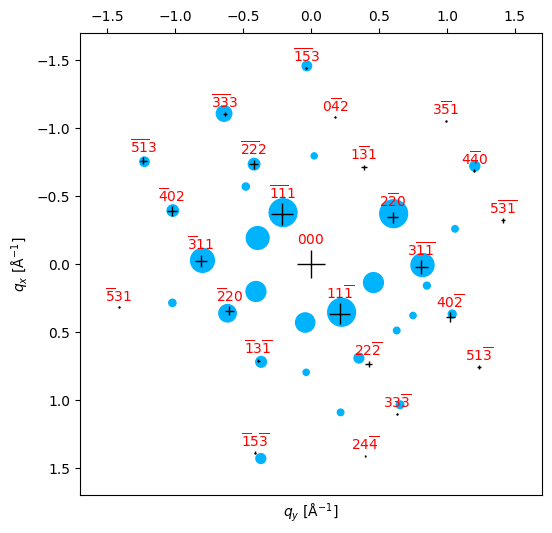

In [29]:
sigma_compare = 0.03   # excitation error for the simulated patterns
xind, yind = 40, 93

plot_params = {
    'scale_markers': 2000,
    'scale_markers_compare': 2,
    'plot_range_kx_ky': crystal.k_max + 0.2,
    'min_marker_size': 2,
    'max_marker_size': 400,
}

orientation = crystal.match_single_pattern(
    bragg_peaks_cali.cal[xind, yind],
    num_matches_return = 3,
    verbose = True,
)

peaks_fit = crystal.generate_diffraction_pattern(
    orientation,
    ind_orientation = 0,
    sigma_excitation_error = sigma_compare,
)

py4DSTEM.process.diffraction.plot_diffraction_pattern(
    peaks_fit,
    bragg_peaks_compare = bragg_peaks_cali.cal[xind, yind],
    **plot_params,
)

## Match every pattern

Some probe positions (e.g. overlapping wires) genuinely contain more than one crystal — `num_matches_return` can return several matches per position. For speed in this tutorial we keep only the best match. This step takes several minutes:

In [30]:
orientation_map = crystal.match_orientations(
    bragg_peaks_cali,
    num_matches_return = 1,
    min_number_peaks = 3,
)

Matching Orientations: 100%|██████████| 8866/8866 [02:05<00:00, 70.71 PointList/s]


# The orientation map

The standard visualization colors each probe position by where its zone axis (out-of-plane) and in-plane directions fall in the crystal's symmetry triangle — the same inverse-pole-figure coloring used in EBSD. Uniformly colored segments are single grains; speckle marks weakly diffracting or ambiguous positions (the correlation panel shows the match confidence).

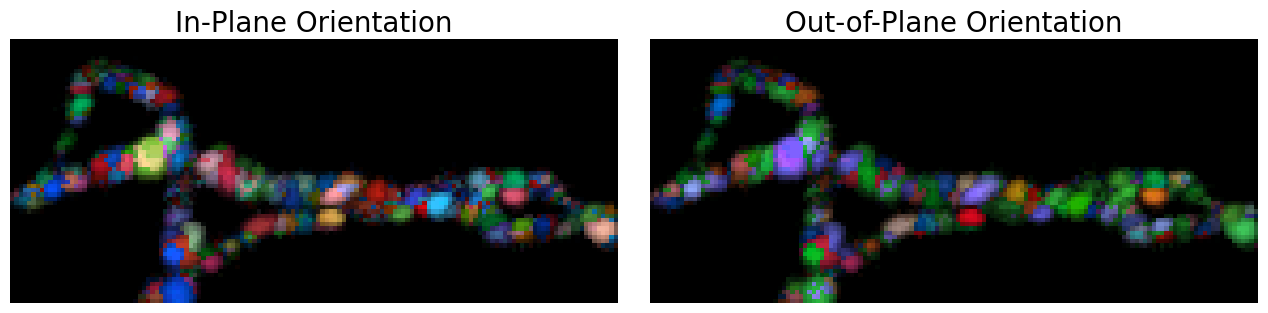

In [31]:
images_orientation = crystal.plot_orientation_maps(
    orientation_map,
    orientation_ind = 0,
    corr_range = np.array([1, 4]),
    camera_dist = 10,
    show_axes = False,
    show_legend = False,
)

# Recap and things to try

You built a nanometer-resolution crystal orientation map from scratch: disk detection → beamstop masking → center/ellipse from a diffraction ring → pixel size from a known lattice → orientation dictionary → per-pattern matching.

Some experiments to try:

- Re-run `match_single_pattern` at several positions with `num_matches_return = 3` and inspect the runner-up matches — where are they nearly degenerate, and why (symmetry, few peaks)?
- Refine the orientation plan (`angle_step_zone_axis = 0.5, angle_coarse_zone_axis = 2.0, angle_refine_range = 2.0`) and compare the maps.
- The next notebook applies exactly this machinery to a *two-phase* titanium alloy — adding phase mapping and strain.